# **Homework 2: Hierarchical models & Gibbs sampling**
STAT 348, UChicago, Spring 2026

----------------
**Your name here: Oleg Glotov**

**Hours spent: 14**

(Please let us know how many hours in total you spent on this assignment so we can calibrate for future assignments. Your feedback is always welcome!)

----------------

<a href="https://colab.research.google.com/github/aschein/stat_348_2026/blob/main/assignments/hw2/hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

## Instructions

This homework focuses on themes in the first four lectures and will also get you working more with Python and PyTorch.

Assignment is due **Monday April 13, 11:59pm** on GradeScope.


## Hierarchical model for noisy survey data

We will consider a model for grouped survey data, where there are $n$ respondents in each of $G$ groups. For each respondent $i \in \{1,\dots, n\}$ in each group $g \in\{1,\dots,G\}$, we observe their covariates $\mathbf{x}_{g,i} \in \mathbb{R}^p$ and a scalar summary of their responses $y_{g,i} \in \mathbb{R}$.

We know that some percentage of each group contains respondents who fill out their survey randomly. (This sometimes happens with paid survey work, like on Mechanical Turk.) We don't know for certain whether any individual respondent answered randomly, so we will use a latent variable model to get denoised estimates of regression coefficients, group-specific means, and other quantities.

Consider the following model for noisy grouped survey data. For each respondent $i \in \{1,\dots, n\}$ in each group $g \in\{1,\dots,G\}$, their response is conditionally Gaussian:
$$
\begin{align*}
y_{g,i} &\sim \begin{cases}
\mathcal{N}(\mathbf{x}_{g,i}^\top \boldsymbol{\beta}_g,\, \sigma_g^2) &\textrm{if } z_{g,i} = 1 \\[0.5em]
\mathcal{N}(\mu_0,\, \sigma_0^2) &\textrm{if } z_{g,i} = 0 \\
\end{cases}
\end{align*}
$$
where $z_{g,i} =1$ means that the respondent did not answer randomly and $z_{g,i}=0$ means they did. We don't observe $z_{g,i}$ and treat it as a latent variable:
$$
\begin{align*}
z_{g,i} &\sim \textrm{Bernoulli}(\rho_g) \\
\rho_g &\sim \textrm{Beta}(\alpha_{0,1}, \alpha_{0,2})
\end{align*}
$$
where $\rho_g \in (0,1)$ is the group-specific rate of "good" respondents, for which we assume a conditionally conjugate Beta prior with hyperparameter $\boldsymbol{\alpha}_{0}=[\alpha_{0,1}, \alpha_{0,2}]$. 

We further assume the following conditionally conjugate hierarchical prior over the regression parameters for non-random "good" responses:
$$
\begin{align*}
(\boldsymbol{\beta}_g, \sigma_g^2) &\sim \textrm{NIX}(\textbf{m}, L_0, \nu_0, \tau_0^2) \\
\textbf{m} &\sim \mathcal{N}(0, I)
\end{align*}
$$
We assume that the random responses follow a Gaussian $\mathcal{N}(\mu_0,\, \sigma_0^2)$ whose hyperparameters we know.

The full set of hyperparameters in the model is $\boldsymbol{\eta}_0 = \{\mu_0, \sigma_0^2, \boldsymbol{\alpha}_0, L_0, \nu_0, \tau_0^2\}$.


---

## **Problem 0:** Draw the graphical model [Visual].

Using either sofware (e.g., TikZ, Keynote) or **very neat handwriting**, create a probabilistic graphical model that describes the generative process above. Your PGM should:
- Use plate notation to denote repeated sampling.
- Use shaded circular nodes to denote observed variables.
- Use un-shaded circular nodes to denote latent variables.
- Use square or bullet-nodes to denote hyperparameters.

Include your image in the space below.

---
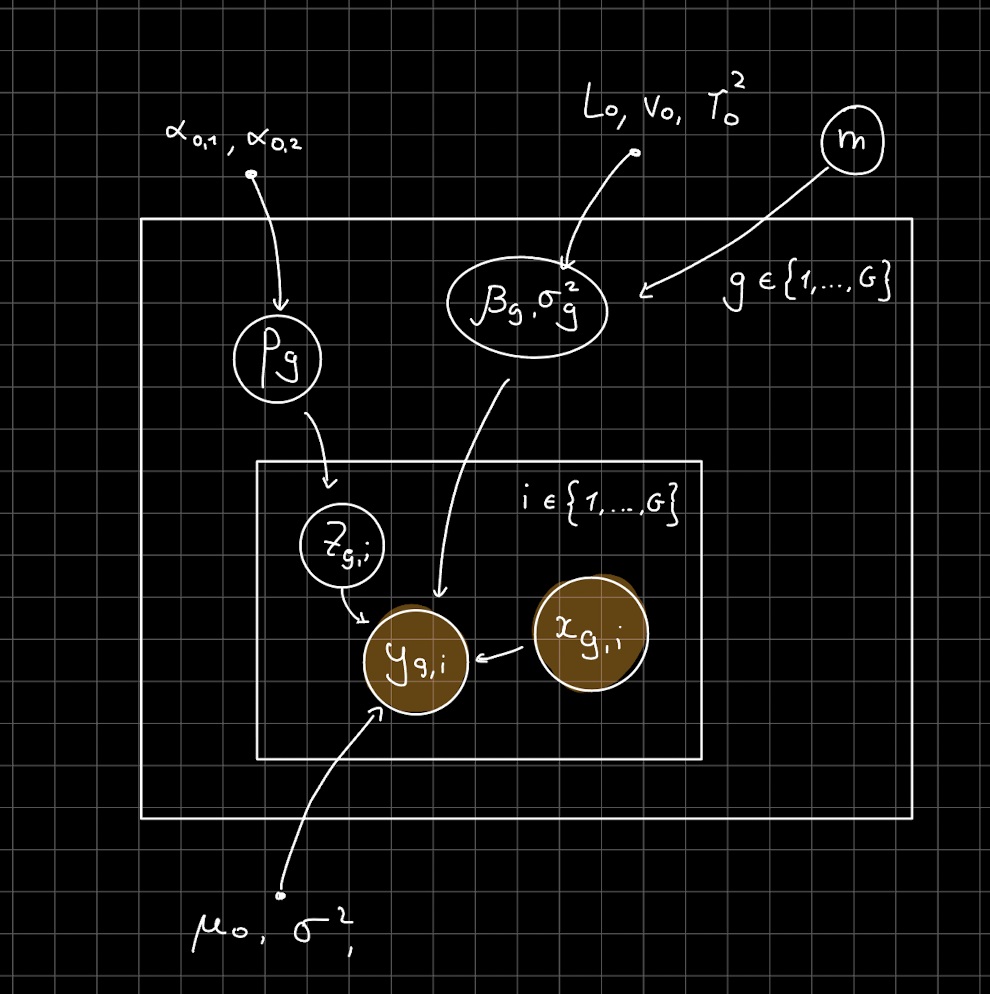
---

## Useful distribution objects

For your convenience, we have implemented as `torch.distributions` the `ScaledInvChiSq` and `NIX` distributions below. We will use these distribution objects to implement the generative process in the code below, and you should use them when implementing your Gibbs sampler.

In [2]:
import torch
from torch.distributions import Gamma, TransformedDistribution, MultivariateNormal
from torch.distributions.transforms import PowerTransform

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("notebook")

class ScaledInvChiSq(TransformedDistribution):
    def __init__(self, dof, scale):
        """
        Implementation of the scaled inverse \chi^2 distribution,

        ..math:
            \chi^{-2}(\nu_0, \sigma_0^2)

        It is equivalent to an inverse gamma distribution, which we implement
        as a transformation of a Gamma distribution. Thus, this class inherits
        functions like `log_prob` from its parent.

        Args:
            dof:   degrees of freedom parameter
            scale: scale of the $\chi^{-2}$ distribution.
        """
        base = Gamma(dof / 2, dof * scale / 2)
        transforms = [PowerTransform(-1)]
        TransformedDistribution.__init__(self, base, transforms)
        self.dof = dof
        self.scale = scale

    def sample(self, sample_shape=torch.Size()):
        """
        Generate samples from the scaled inverse chi-squared distribution.

        Args:
            sample_shape: Shape of the samples to generate.

        Returns:
            Samples from the distribution.
        """
        inv_gamma_samples = super().sample(sample_shape)
        return inv_gamma_samples

class NIX:
    def __init__(self, m, L, nu, tausq):
        """
        Implementation of the Normal-Inverse-Chi-Squared (NIX) distribution.

        Args:
            m: mean of the weights (tensor of shape (p,))
            L: precision matrix of the weights (tensor of shape (p, p))
            nu: degrees of freedom (scalar tensor)
            tausq: scale of the variance parameter (scalar tensor)
        """
        self.m = m
        self.L = L
        self.nu = nu
        self.tausq = tausq

    def sample(self, sample_shape=torch.Size()):
        """
        Generate samples from the NIX distribution.

        Args:
            sample_shape: Shape of the samples to generate.

        Returns:
            beta_samples: Samples of the weights (tensor of shape (*sample_shape, p))
            sigmasq_samples: Samples of the variance (tensor of shape (*sample_shape,))
        """
        sigmasq_samples = ScaledInvChiSq(self.nu, self.tausq).sample(sample_shape)
        L_inv = torch.inverse(self.L)
        beta_samples = MultivariateNormal(self.m, sigmasq_samples[..., None, None] * L_inv).sample()
        return beta_samples, sigmasq_samples

## The "forward" sampler

For your convenience, we have also implemented a function to sample from prior (i.e., the "forward" sampler in `sample_state_forward`). This will yield a dictionary of latent variables that we call the model's `state`.

We have also implemented a function to sample from the likelihood in `sample_Y`, which takes in a model `state` and returns a sample from the likelihood. This function relies on another function called `get_likelihood` which returns a `torch.distributions.Normal` object; this function may be useful to you in what you implement, so we recommend you study the code.

The code here also contains examples of how to sample from PyTorch distribution objects without using for-loops (which are very slow in Python), along with examples of indexing, `torch.einsum`, and various other snippets of code that you may find useful.


In [3]:
from torch.distributions import Normal, Beta, Bernoulli

def sample_state_forward(X, hypers):
    """
    Samples the state variables for the forward sampler.

    Args:
        X (torch.Tensor): covariates (groups x respondents x features)
        hypers (dict): dictionary containing the hyperparameters
            - "L_0": torch.Tensor, prior precision matrix of shape (p, p)
            - "nu_0": float, prior degrees of freedom
            - "tausq_0": float, prior scale of variance
            - "alpha": tuple of floats, parameters of the Beta distribution

    Returns:
        dict
            A dictionary containing the sampled state variables:
            - "m_P": torch.Tensor, sampled prior mean of shape (p,)
            - "beta_GP": torch.Tensor, sampled regression coefficients of shape (G, p)
            - "sigmasq_G": torch.Tensor, sampled variances of shape (G,)
            - "rho_G": torch.Tensor, sampled probabilities of shape (G,)
            - "Z_GN": torch.Tensor, sampled binary indicators of shape (G, n)
    """
    G, n, p = X.shape
    m_P = Normal(0, 1).sample((p,))
    beta_GP, sigmasq_G = NIX(m=m_P,
                             L=hypers["L_0"], 
                             nu=hypers["nu_0"], 
                             tausq=hypers["tausq_0"]).sample(sample_shape=(G,))
    
    alpha1, alpha2 = hypers["alpha"]
    rho_G = Beta(alpha1, alpha2).sample((G,))
    Z_GN = Bernoulli(rho_G).sample((n,)).T

    state = {
        "m_P": m_P,
        "beta_GP": beta_GP,
        "sigmasq_G": sigmasq_G,
        "rho_G": rho_G,
        "Z_GN": Z_GN
    }
    return state


def get_likelihood(X, state, hypers):
    """
        Computes the likelihood of the observed data given the current state and hyperparameters.

        Args:
            X (torch.Tensor): covariates (groups x respondents x features)
            state (dict): dictionary containing the current state variables
            hypers (dict): dictionary containing the hyperparameters

        Returns:
            torch.distributions.Normal: A Normal distribution object representing the likelihood
                of the observed data given the current state and hyperparameters.
    """
    G, n, p = X.shape
    mu_0, sigmasq_0 = hypers["mu_0"], hypers["sigmasq_0"]
    beta_GP, sigmasq_G, Z_GN = [state[key] for key in ["beta_GP", "sigmasq_G", "Z_GN"]]

    mu_GN = torch.einsum("gj,gij->gi", beta_GP, X)
    mu_GN[Z_GN == 0] = mu_0

    sigmasq_GN = sigmasq_G.repeat(n, 1).T
    sigmasq_GN[Z_GN == 0] = sigmasq_0
    return Normal(mu_GN, torch.sqrt(sigmasq_GN))


def sample_Y(X, state, hypers):
    """
        Generates synthetic data based on the current state and hyperparameters.

        Args:
            X (torch.Tensor): covariates (groups x respondents x features)
            state (dict): dictionary containing the current state variables
            hypers (dict): dictionary containing the hyperparameters

        Returns:
            torch.Tensor: Y sampled from the likelihood distribution (groups x respondents)
    """
    return get_likelihood(X, state, hypers).sample()

## **Problem 1:** Derive the complete conditionals [Math]

### **1a):** Derive the complete conditional distribution $p(z_{g,i} \mid -)$. Here the $-$ notation means "everything", which includes $\textbf{X}$, $\textbf{Y}$, all latent variables other than $z_{g,i}$, and all hyperparameters.

---

From Q0 we know $z_{g,i}$ only depends on its parent $\rho_g$, its child $y_{g,i}$, and the co-parents ${\beta}_g, \sigma_g^2, \mathbf{x}_{g,i}, \mu_0, \sigma_0^2$.

The complete conditional is proportional to the prior times the likelihood:

$$
p(z_{g,i} \mid -) \propto p(z_{g,i} \mid \rho_g) \cdot p(y_{g,i} \mid z_{g,i}, {\beta}_g, \sigma_g^2, \mathbf{x}_{g,i})
$$

Check both cases. 

For $z_{g,i} = 1$:

$$
p(z_{g,i} = 1 \mid -) \propto \rho_g \cdot \mathcal{N}(y_{g,i} \mid \mathbf{x}_{g,i}^T {\beta}_g, \sigma_g^2)
$$

For $z_{g,i} = 0$:

$$
p(z_{g,i} = 0 \mid -) \propto (1 - \rho_g) \cdot \mathcal{N}(y_{g,i} \mid \mu_0, \sigma_0^2)
$$

Since $z_{g,i}$ is binary these must sum to 1. 

Let $\ell_1 = \mathcal{N}(y_{g,i} \mid \mathbf{x}_{g,i}^T {\beta}_g, \sigma_g^2)$ and $\ell_0 = \mathcal{N}(y_{g,i} \mid \mu_0, \sigma_0^2)$. Normalizing:

$$
p(z_{g,i} = 1 \mid -) = \frac{\rho_g \cdot \ell_1}{\rho_g \cdot \ell_1 + (1 - \rho_g) \cdot \ell_0}
$$

So by pluggin in:

$$
\mathbf{\rho}_{g,i} = \frac{\rho_g \cdot \ell_1}{\rho_g \cdot \ell_1 + (1 - \rho_g) \cdot \ell_0}
$$

The complete conditional is:

$p(z_{g,i} \mid -) = \text{Bernoulli}(\mathbf{\rho}_{g,i})$ 

---

### **1b):** Derive the complete conditional of $\rho_{g}$.

---

Similar to before we have $\rho_g$ dependance on its parents $(\alpha_{0,1}, \alpha_{0,2})$ and its children $\{z_{g,1}, \ldots, z_{g,n}\}$.

The complete conditional is proportional to the prior times the likelihood of the children.

The prior is Beta:

$$
p(\rho_g) = \text{Beta}(\alpha_{0,1}, \alpha_{0,2}) \text{ or } \rho_g^{\alpha_{0,1} - 1}(1 - \rho_g)^{\alpha_{0,2} - 1}
$$

The likelihood is a product of Bernoullis:

$$
\prod_{i=1}^n p(z_{g,i} \mid \rho_g) = \prod_{i=1}^n \rho_g^{z_{g,i}} (1 - \rho_g)^{1 - z_{g,i}}
$$

$$
= \rho_g^{\sum_i z_{g,i}} (1 - \rho_g)^{\sum_i (1 - z_{g,i})}
$$

Now combine together:

$$
p(\rho_g \mid -) \propto \rho_g^{\alpha_{0,1} - 1}(1 - \rho_g)^{\alpha_{0,2} - 1} \cdot \rho_g^{\sum_i z_{g,i}} (1 - \rho_g)^{\sum_i (1 - z_{g,i})}
$$

Exponents of $\rho_g$ and $(1 - \rho_g)$:

$$
= \rho_g^{\alpha_{0,1} + \sum_i z_{g,i} - 1} (1 - \rho_g)^{\alpha_{0,2} + \sum_i (1 - z_{g,i}) - 1}
$$

So we end with a kernel of a Beta distribution:

$p(\rho_{g} \mid -) = \text{Beta}\left(\alpha_{0,1} + \sum_{i=1}^n z_{g,i},\;\; \alpha_{0,2} + \sum_{i=1}^n (1 - z_{g,i})\right)$ 

---

### **1c):** Derive the complete conditional of $(\boldsymbol{\beta}_g, \sigma_g^2)$.

---

As before, $({\beta}_g, \sigma_g^2)$ depends on its parents $(\mathbf{m}, L_0, \nu_0, \tau_0^2)$ and its children $\{y_{g,i}\}$ with co-parents $\{z_{g,i}, \mathbf{x}_{g,i}\}$.

The complete conditional written out is:

$$
p({\beta}_g, \sigma_g^2 \mid -) \propto p({\beta}_g, \sigma_g^2 \mid \mathbf{m}, L_0, \nu_0, \tau_0^2) \cdot \prod_{i=1}^n p(y_{g,i} \mid z_{g,i}, {\beta}_g, \sigma_g^2, \mathbf{x}_{g,i})
$$

When $z_{g,i} = 0$ the likelihood is $\mathcal{N}(y_{g,i} \mid \mu_0, \sigma_0^2)$ which is indep. of ${\beta}_g$ or $\sigma_g^2$. So those terms are constants and we can drop them:

$$
\prod_{i=1}^n p(y_{g,i} \mid z_{g,i}, {\beta}_g, \sigma_g^2, \mathbf{x}_{g,i}) \propto \prod_{i:\, z_{g,i}=1} \mathcal{N}(y_{g,i} \mid \mathbf{x}_{g,i}^T {\beta}_g, \sigma_g^2)
$$

Only the true respondents ($z = 1$) contribute. If $n_g = \sum_{i=1}^n z_{g,i}$ are the number of real respondents in group $g$. Let $\mathbf{y}_g^*$ and $X_g^*$ be the responses and covariates of only these real respondents.

Given the prior NIX from the model:

$$
p(\boldsymbol{\beta}_g, \sigma_g^2 \mid \mathbf{m}, L_0, \nu_0, \tau_0^2) = \text{NIX}(\mathbf{m}, L_0, \nu_0, \tau_0^2)
$$

The complete conditional becomes:

$$
p(\boldsymbol{\beta}_g, \sigma_g^2 \mid -) \propto \text{NIX}(\boldsymbol{\beta}_g, \sigma_g^2; \mathbf{m}, L_0, \nu_0, \tau_0^2) \cdot \prod_{i:\, z_{g,i}=1} \mathcal{N}(y_{g,i} \mid \mathbf{x}_{g,i}^T \boldsymbol{\beta}_g, \sigma_g^2)
$$

This is exactly the same setup as HW1 Problem 1: a NIX prior times a Gaussian likelihood.

By the same conjugacy result from HW1:

$$
p(\boldsymbol{\beta}_g, \sigma_g^2 \mid -) = \text{NIX}(\mathbf{m}_n^{(g)}, L_n^{(g)}, \nu_n^{(g)}, {\tau_n^{(g)}}^2)
$$

where

$$
\nu_n^{(g)} = \nu_0 + n_g
$$

$$
L_n^{(g)} = L_0 + {X_g^*}^T X_g^*
$$

$$
\mathbf{m}_n^{(g)} = {L_n^{(g)}}^{-1}(L_0 \mathbf{m} + {X_g^*}^T \mathbf{y}_g^*)
$$

$$
{\tau_n^{(g)}}^2 = \frac{1}{\nu_n^{(g)}}\left(\nu_0 \tau_0^2 + {\mathbf{y}_g^*}^T \mathbf{y}_g^* + \mathbf{m}^T L_0 \mathbf{m} - {\mathbf{m}_n^{(g)}}^T L_n^{(g)} \mathbf{m}_n^{(g)}\right)
$$

Note: the prior mean here is $\mathbf{m}$, not a fixed hyperparameter. Also data is filtered for real respondents only.

---

### **1d):** Derive the complete conditional of $\textbf{m}$.

---



As before $\mathbf{m}$ depends on its children $\{{\beta}_g\}_{g=1}^G$ and the co-parents $\{\sigma_g^2\}_{g=1}^G, L_0$.

The complete conditional is:

$$
p(\mathbf{m} \mid -) \propto p(\mathbf{m}) \cdot \prod_{g=1}^G p({\beta}_g \mid \sigma_g^2, \mathbf{m}, L_0)
$$

The prior on $\mathbf{m}$ is:

$$
p(\mathbf{m}) = \mathcal{N}(\mathbf{m} \mid \mathbf{0}, I)
$$

For the likelihood term refer to the NIX prior on $({\beta}_g, \sigma_g^2)$ can be written as:

$$
\text{NIX}(\mathbf{m}, L_0, \nu_0, \tau_0^2) = \chi^{-2}(\sigma_g^2 \mid \nu_0, \tau_0^2) \cdot \mathcal{N}({\beta}_g \mid \mathbf{m}, \sigma_g^2 L_0^{-1})
$$

The $\chi^{-2}$ part does not involve $\mathbf{m}$, so it is a constant. We only keep the Gauss:

$$
p({\beta}_g \mid \sigma_g^2, \mathbf{m}, L_0) \propto \mathcal{N}({\beta}_g \mid \mathbf{m}, \sigma_g^2 L_0^{-1})
$$

Subbin in:

$$
p(\mathbf{m} \mid -) \propto \mathcal{N}(\mathbf{m} \mid \mathbf{0}, I) \cdot \prod_{g=1}^G \mathcal{N}({\beta}_g \mid \mathbf{m}, \sigma_g^2 L_0^{-1})
$$

Here we can refer to lecture 2 slides for Gauss-Gauss conjugacy. The prior on $\mathbf{m}$ is Gaussian and each ${\beta}_g$ acts like a "data point" with mean $\mathbf{m}$ and known covariance $\sigma_g^2 L_0^{-1}$ and so precision $\frac{1}{\sigma_g^2} L_0$).

The posterior precision is:

$$
\ell = I + \sum_{g=1}^G \frac{1}{\sigma_g^2} L_0
$$

For the posterior mean where the prior contributes $I \cdot \mathbf{0} = \mathbf{0}$. Each data point contributes $\frac{1}{\sigma_g^2} L_0 {\beta}_g$. So:

$$
\mathbf{m}_{\text{post}} = \ell^{-1} \left(\sum_{g=1}^G \frac{1}{\sigma_g^2} L_0 {\beta}_g \right)
$$

The complete conditional is:

$$
p(\textbf{m} \mid -) = \mathcal{N}(\mathbf{m}_{\text{post}}, \ell^{-1})
$$

where

$$
\ell = I + \sum_{g=1}^G \frac{1}{\sigma_g^2} L_0, \quad \mathbf{m}_{\text{post}} = \ell^{-1} \left(\sum_{g=1}^G \frac{1}{\sigma_g^2} L_0 {\beta}_g \right)
$$

---

## **Problem 2:** Implement the complete conditionals [Code]

**2a):** Implement the complete conditional of $z_{g,i}$.

For this, you should make sure your implementation is numerically stable by computing things in log-space using the **logsumexp trick**. You can read about the math of the logsumexp trick [here]((https://gregorygundersen.com/blog/2020/02/09/log-sum-exp/)). Your implementation should involve `torch.logsumexp` which you can read about [here](https://pytorch.org/docs/stable/generated/torch.logsumexp.html).

In [4]:
def update_Z_GN(Y, X, state, hypers):
    """
    Update the binary latent variable Z_GN based on the current state, data, 
    and hyperparameters. This function should compute the log-probabilities for 
    Z_GN being 0 vs 1, normalizes them in log-space to log-probabilities, and then 
    samples new values for Z_GN from the resulting Bernoulli distribution.

    Args:
        Y (torch.Tensor): Observed responses (groups x respondents).
        X (torch.Tensor): Covariates (groups x respondents x features).
        state (dict): Current state of the model containing latent variables.
        hypers (dict): Dictionary of hyperparameters.

        NOTE: By default, we pass (Y, X, state, hypers) to all complete conditionals,
        however certain complete conditionals may not require some of these inputs.

    Returns:
        None: Updates the 'Z_GN' key in the state dictionary in-place.
    
    """
    # REAL
    beta_g_p = state["beta_GP"]
    sigmasq_g = state["sigmasq_G"]
    rho_g = state["rho_G"]

    mu_g_n = torch.einsum("gnp,gp->gn", X, beta_g_p)

    std_g_n = torch.sqrt(sigmasq_g[:, None])  # (G, 1) to (G, n)
    log_like_real = Normal(mu_g_n, std_g_n).log_prob(Y)  # (G, n)

    log_score_real = torch.log(rho_g[:, None]) + log_like_real  # (G, n)

    mu_0 = hypers["mu_0"]
    sigmasq_0 = hypers["sigmasq_0"]

    # FAKE
    log_like_fake = Normal(mu_0, torch.sqrt(torch.tensor(sigmasq_0))).log_prob(Y)  # (G, n)

    log_score_fake = torch.log(1 - rho_g[:, None]) + log_like_fake  # (G, n)

    # NORMALIZE
    log_scores = torch.stack([log_score_fake, log_score_real], dim=0)  # (2, G, n)
    log_p_GN = log_score_real - torch.logsumexp(log_scores, dim=0)  # (G, n)
    # log_p_GN = ... [G, n] tensor
    

    p_GN = torch.exp(log_p_GN)
    assert torch.isfinite(p_GN).all()
    state['Z_GN'] = Bernoulli(p_GN).sample()

**2b):** Implement the complete conditional of $\rho_{g}$.

In [5]:
def update_rho_G(Y, X, state, hypers):
    """ Update the probabilities rho_G based on the current state, data, 
    and hyperparameters. 

    Args:
        Y (torch.Tensor): Observed responses (groups x respondents).
        X (torch.Tensor): Covariates (groups x respondents x features).
        state (dict): Current state of the model containing latent variables.
        hypers (dict): Dictionary of hyperparameters containing:

    Returns:
        None: Updates the 'rho_G' key in the state dictionary in-place.
    """

    Z_g_n = state["Z_GN"]
    alpha1 = hypers["alpha"][0]
    alpha2 = hypers["alpha"][1]

    # print(" ----- LOG -----" + str(alpha1) + " " + str(alpha2))

    param1 = alpha1 + Z_g_n.sum(dim=1)  # (G,)
    param2 = alpha2 + Z_g_n.shape[1] - Z_g_n.sum(dim=1)  # (G,)

    rho_G = Beta(param1, param2).sample()  # (G,)


    # YOUR CODE HERE
    # rho_G = ...

    state['rho_G'] = rho_G

**2c):** Implement the complete conditional of $(\boldsymbol{\beta}_g, \sigma_g^2)$.

**Hint:** you have derivations and code from HW1 that you could re-use.

In [6]:
def update_regression_params(Y, X, state, hypers):
    """ Update the regression parameters based on the current state, data, 
    and hyperparameters. 

    Args:
        Y (torch.Tensor): Observed responses (groups x respondents).
        X (torch.Tensor): Covariates (groups x respondents x features).
        state (dict): Current state of the model containing latent variables.
        hypers (dict): Dictionary of hyperparameters containing:

    Returns:
        None: Updates the 'beta_GP' and `sigmasq_G' keys in the state dictionary in-place.
    """

    G, n, p = X.shape
    Z_g_n = state["Z_GN"]
    m = state["m_P"]
    L_0 = hypers["L_0"]
    nu_0 = hypers["nu_0"]
    tausq_0 = hypers["tausq_0"]

    for g in range(G):
        mask = Z_g_n[g] == 1
        X_g = X[g][mask] # (n_g, p)
        y_g = Y[g][mask] # (n_g,)

        # Same formulas as HW1 compute_posterior
        n_g = mask.sum()
        nu_n = nu_0 + n_g
        L_n = L_0 + X_g.T @ X_g
        m_n = torch.linalg.solve(L_n, X_g.T @ y_g + L_0 @ m)

        nu_n_tausq_n = (nu_0 * tausq_0
                        + y_g @ y_g
                        + m @ L_0 @ m
                        - m_n @ L_n @ m_n)
        tausq_n = nu_n_tausq_n / nu_n

        beta_g, sigmasq_g = NIX(m=m_n, L=L_n, nu=nu_n, tausq=tausq_n).sample()

        state["beta_GP"][g] = beta_g
        state["sigmasq_G"][g] = sigmasq_g

**2d):** Implement the complete conditional of $\textbf{m}$.


In [7]:
def update_m_P(Y, X, state, hypers):
    """ Update the mean of regression coefficients m_P based on the current state, data, 
    and hyperparameters. 

    Args:
        Y (torch.Tensor): Observed responses (groups x respondents).
        X (torch.Tensor): Covariates (groups x respondents x features).
        state (dict): Current state of the model containing latent variables.
        hypers (dict): Dictionary of hyperparameters containing:

    Returns:
        None: Updates the 'm_P' key in the state dictionary in-place.
    """

    beta_g_p = state["beta_GP"]
    sigmasq_g = state["sigmasq_G"]
    L_0 = hypers["L_0"]

    G, p = beta_g_p.shape

    # Posterior precision
    Lambda = torch.eye(p)
    weighted_sum = torch.zeros(p)
    for g in range(G):
        Lambda = Lambda + (1 / sigmasq_g[g]) * L_0
        weighted_sum = weighted_sum + (1 / sigmasq_g[g]) * L_0 @ beta_g_p[g]

    # Posterior mean
    m_post = torch.linalg.solve(Lambda, weighted_sum)

    # Sample
    state["m_P"] = MultivariateNormal(m_post, precision_matrix=Lambda).sample()


In [8]:
# TEST CELL - chatgpt generated - IGNORE

# Quick sanity test for individual update functions
from torch.distributions import Normal, Beta, Bernoulli

G, n, p = 3, 10, 2
X = Normal(0, 1).sample((G, n, p))
X[:, :, 0] = 1.0

hypers = {"m_0": torch.zeros(p),
          "L_0": torch.eye(p),
          "nu_0": 1.0,
          "tausq_0": 0.1,
          "alpha": torch.Tensor([5., 1.]),
          "mu_0": -5.0,
          "sigmasq_0": 2.0}

# Generate a valid state from the forward sampler
state = sample_state_forward(X, hypers)
Y = sample_Y(X, state, hypers)

print("Before update_Z_GN:")
print("  Z_GN shape:", state["Z_GN"].shape, "  mean:", state["Z_GN"].mean().item())

update_Z_GN(Y, X, state, hypers)
print("After update_Z_GN:")
print("  Z_GN shape:", state["Z_GN"].shape, "  mean:", state["Z_GN"].mean().item())
print("  All 0 or 1?", ((state["Z_GN"] == 0) | (state["Z_GN"] == 1)).all().item())


# --------- 
print("------------")


print("Before update_rho_G:")
print("  rho_G:", state["rho_G"])

update_rho_G(Y, X, state, hypers)

print("After update_rho_G:")
print("  rho_G:", state["rho_G"])
print("  Shape:", state["rho_G"].shape)
print("  All in (0,1)?", (state["rho_G"] > 0).all().item() and (state["rho_G"] < 1).all().item())


print("------------")

print("Before update_regression_params:")
print("  beta_GP:\n", state["beta_GP"])
print("  sigmasq_G:", state["sigmasq_G"])

update_regression_params(Y, X, state, hypers)

print("After update_regression_params:")
print("  beta_GP:\n", state["beta_GP"])
print("  sigmasq_G:", state["sigmasq_G"])
print("  sigmasq_G > 0?", (state["sigmasq_G"] > 0).all().item())
print("  beta_GP shape:", state["beta_GP"].shape)
print("  sigmasq_G shape:", state["sigmasq_G"].shape)
print("  Any NaN?", torch.isnan(state["beta_GP"]).any().item() or torch.isnan(state["sigmasq_G"]).any().item())


print("------------")


print("Before update_m_P:")
print("  m_P:", state["m_P"])

update_m_P(Y, X, state, hypers)

print("After update_m_P:")
print("  m_P:", state["m_P"])
print("  Shape:", state["m_P"].shape)
print("  Any NaN?", torch.isnan(state["m_P"]).any().item())


Before update_Z_GN:
  Z_GN shape: torch.Size([3, 10])   mean: 0.699999988079071
After update_Z_GN:
  Z_GN shape: torch.Size([3, 10])   mean: 0.6666666865348816
  All 0 or 1? True
------------
Before update_rho_G:
  rho_G: tensor([0.7426, 0.9848, 0.3261])
After update_rho_G:
  rho_G: tensor([0.9008, 0.9086, 0.5340])
  Shape: torch.Size([3])
  All in (0,1)? True
------------
Before update_regression_params:
  beta_GP:
 tensor([[-0.0257, -1.0170],
        [-0.0247, -1.0014],
        [-0.2805, -1.9226]])
  sigmasq_G: tensor([0.0191, 0.0482, 0.6455])
After update_regression_params:
  beta_GP:
 tensor([[ 0.0248, -1.0128],
        [-0.0702, -0.9858],
        [ 0.4084, -0.7009]])
  sigmasq_G: tensor([0.0414, 0.0323, 0.1497])
  sigmasq_G > 0? True
  beta_GP shape: torch.Size([3, 2])
  sigmasq_G shape: torch.Size([3])
  Any NaN? False
------------
Before update_m_P:
  m_P: tensor([ 0.1412, -1.1495])
After update_m_P:
  m_P: tensor([-0.0791, -0.9665])
  Shape: torch.Size([2])
  Any NaN? False


## Gibbs sampler

For your convenience, we have implemented the function `gibbs` which relies on the complete conditionals you implemented in problem 2.

In [9]:
from copy import deepcopy
from tqdm.notebook import tqdm

def get_gibbs_transition(Y, X, hypers):
    """Returns a function that performs a single Gibbs transition
    
    Args:
        Y (torch tensor): responses (groups x respondents)
        X (torch tensor): covariates (groups x respondents x features)
        hypers (dict): dictionary containing the hyperparameters
    
    Returns:
        function: function that performs a single Gibbs transition
    """
    def gibbs_transition(state):
        update_Z_GN(Y, X, state, hypers)
        update_rho_G(Y, X, state, hypers)
        update_regression_params(Y, X, state, hypers)
        update_m_P(Y, X, state, hypers)
        return state

    return gibbs_transition


def gibbs(Y, X, hypers, n_samples=250, n_burnin=100, n_thin=5):
    """Gibbs sampler

    Args:
        Y (torch tensor): responses (groups x respondents)
        X (torch tensor): covariates (groups x respondents x features)
        hypers (dict): dictionary containing the hyperparameters
        n_samples (int, optional): number of posterior samples to collect. 
        n_burnin (int, optional): number of burn-in samples.
        n_thin (int, optional): thinning parameter. Only collect every n_thin samples.
    
    Returns:
        posterior_samples (list): list of posterior samples, each sample is a state dictionary
    """
    # initialize the state from the prior
    state = sample_state_forward(X, hypers)
    
    # get the transition operator
    gibbs_transition = get_gibbs_transition(Y, X, hypers)

    # burn-in samples
    for _ in tqdm(range(n_burnin)):
        state = gibbs_transition(state)
    
    posterior_samples = []
    for m in tqdm(range(n_samples * n_thin)):
        state = gibbs_transition(state)

        # only collect every n_thin samples
        if m % n_thin == 0:
            # make sure to deepcopy so the code does not modify the collected states
            posterior_samples.append(deepcopy(state)) 
    
    return posterior_samples  

## **Problem 3:** Geweke testing [Code, results]

In this problem you will implement and run a Geweke test to ensure your Gibbs sampler is correctly derived and implemented.

See the lecture notes, along with [Grosse & Duvenaud (2014)](https://arxiv.org/pdf/1412.5218.pdf) and [Geweke (2004)](https://www.jstor.org/stable/27590449) for details on Geweke testing.

In general, a Geweke test compares two sets of samples which should both be iid from the joint distribution $p(\textbf{Y}, \textbf{Z})$ of data $\textbf{Y}$ and latent variables $\textbf{Z}$ (note here $\textbf{Z}$ means **all** latent variables in a model). The first set of samples are the **forward samples** ($\textbf{Y}_m^f$, $\textbf{Z}_m^f)_{m=1}^M$ which are drawn iid:
$$\begin{align*}
\textbf{Z}_m^f &\sim p(\textbf{Z}) & \textrm{prior} \\
\textbf{Y}_m^f &\sim p(\textbf{Y} \mid \textbf{Z}_m^f) &\textrm{likelihood}
\end{align*}
$$
The second set of samples are the **backward samples** ($\textbf{Y}_m^b$, $\textbf{Z}_m^b)_{m=1}^M$ which are drawn using Gibbs sampling:
$$\begin{align*}
\textbf{Z}_m^b &\sim \pi(\textbf{Z} \mid \textbf{Z}_{m-1}^b, \textbf{Y}_{m-1}^f)  & \textrm{Gibbs transition kernel}\\
\textbf{Y}_m^b &\sim p(\textbf{Y} \mid \textbf{Z}_m^b) & \textrm{likelihood}
\end{align*}
$$

**3a):** Finish implementing `geweke_test` below by implementing the backward sampler. The backward sampler should:
- First, initialize all latent variables and data with a draw from the prior / likelihood (i.e., using a forward sample).

- Then, it should run 10,000 iterations of burn-in, and then another 50,000 iterations, saving every 5th sample. The output should be 10,000 samples, each of which is a dictionary containing latent variables **and data**.

- Make sure that your backward sampler is indeed generating samples from the joint distribution.

In [10]:
def geweke_test(X, hypers, n_samples=10000, n_burnin=10000, n_thin=5):
    """Geweke test
    
    Args:
        X (torch tensor): covariates (groups x respondents x features)
        hypers (dict): dictionary containing the hyperparameters
        n_samples (int, optional): number of forward and backward samples to collect.
        n_burnin (int, optional): number of burn-in samples.
        n_thin (int, optional): thinning parameter. Only collect every n_thin samples.
    
    Returns:
        forward_samples (list): list of forward samples, each sample is a state dictionary
        backward_samples (list): list of backward samples, each sample is a state dictionary
    
    References:
        [1] Grosse & Duvenaud (2014) "Testing MCMC Code": https://arxiv.org/pdf/1412.5218.pdf
        [2] Geweke (2004) "Getting it right...": https://www.jstor.org/stable/27590449
    """

    # sample forward from the prior and likelihood
    forward_samples = []
    for _ in tqdm(range(n_samples)):
        state = sample_state_forward(X, hypers)
        state['Y'] = sample_Y(X, state, hypers)
        forward_samples.append(deepcopy(state))  
    
    
    backward_samples = []

    state = sample_state_forward(X, hypers)
    Y = sample_Y(X, state, hypers)

    for _ in tqdm(range(n_burnin)):
        gibbs_transition = get_gibbs_transition(Y, X, hypers)
        state = gibbs_transition(state)
        Y = sample_Y(X, state, hypers)

    for _ in tqdm(range(n_samples * n_thin)):
        gibbs_transition = get_gibbs_transition(Y, X, hypers)
        state = gibbs_transition(state)
        Y = sample_Y(X, state, hypers)

        if _ % n_thin == 0:
            backward_samples.append(deepcopy(state))
    
    return forward_samples, backward_samples

**3b):** Now run the cell below to Geweke test your code. The output should be two PP-plots that compare the means $\rho_g$ and $\mathbf{m}$ between the forward and backward sample. The PP-plots should be **straight along the diagonal**; if they are not straight, there is a bug in the derivation or code (or both) of your Gibbs sampler. For reference, running this took our implementation 3 minutes; if it is much slower for you, you should investigate the bottlenecks in your code.

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

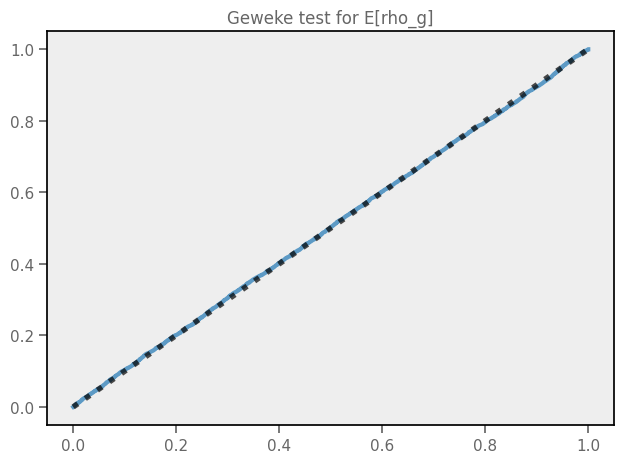

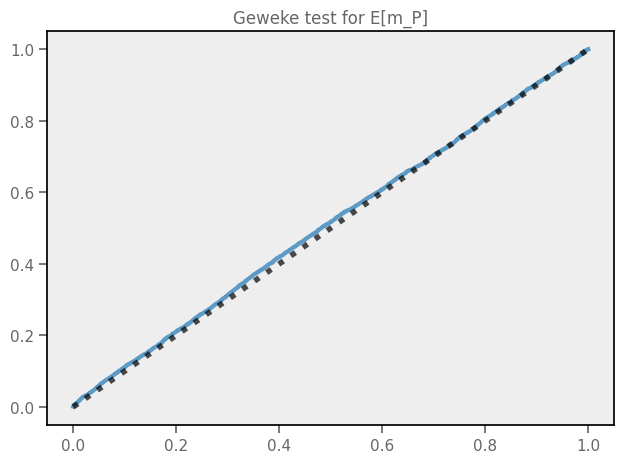

<Figure size 640x480 with 0 Axes>

In [11]:
from pp_plot import pp_plot

# You can/should use small G, p, n for the purposes of testing to speed up the code
# Theoretically, your code should pass the Geweke test for any setting of hyperparams.
G = 3
p = 2
n = 10

X = Normal(0, 0.1).sample((G, n, p))
X[:, :, 0] = 1.0

hypers = {"m_0": torch.zeros(p),
          "L_0": torch.eye(p) * 1,
          "nu_0": 1.0,
          "tausq_0": 0.1,
          "alpha": torch.Tensor([5., 1.]),
          "mu_0": -1.0,
          "sigmasq_0": 2.0}

forward_samples, backward_samples = geweke_test(X=X, 
                                                hypers=hypers, 
                                                n_samples=10000, 
                                                n_burnin=10000, 
                                                n_thin=5)

# Compare the arithmetic mean of the rho_G parameters across samples
arr1 = [state['rho_G'].mean() for state in forward_samples]
arr2 = [state['rho_G'].mean() for state in backward_samples]
pp_plot(arr1, arr2, 'Geweke test for E[rho_g]')

# Compare the arithmetic mean of the m_P parameters across samples
arr1 = [state['m_P'].mean() for state in forward_samples]
arr2 = [state['m_P'].mean() for state in backward_samples]
pp_plot(arr1, arr2, 'Geweke test for E[m_P]')

## **Problem 4:** Gibbs sampling on the real data [Code, plotting, results]

Now load in the "real" training data and run Gibbs sampling for 1000 burn-in, and then another 5000, collecting every 5th sample. This should return 1000 posterior samples. For reference, our implementation runs in 45 seconds. If yours is taking much longer, you should look into your code's bottlenecks.

After running Gibbs sampling, use your posterior samples to visualize the posterior distribution of $\textbf{m}$. There are $p$ dimensions of $\textbf{m}$, so you should create a plot that visualizes posterior uncertainty over all $p$ dimensions (e.g., $p$ histograms).

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

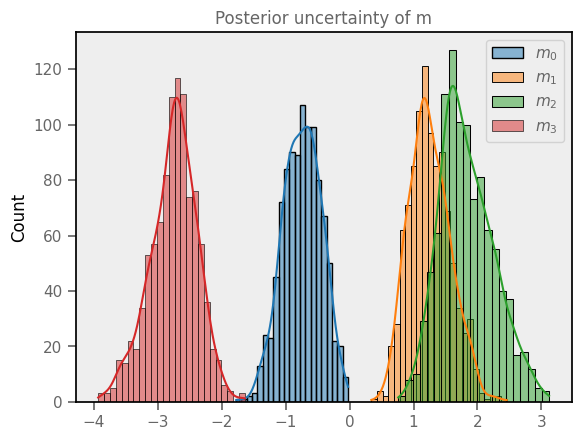

In [12]:
Y_train, X_train = torch.load("data_train.pt")
G, n, p = X_train.shape

hypers = {"L_0": torch.eye(p) * 1,
          "nu_0": 1.0,
          "tausq_0": 0.1,
          "alpha": torch.Tensor([5., 1.]),
          "mu_0": -5.0,
          "sigmasq_0": 2.0}

samples = gibbs(Y_train, X_train, hypers, n_samples=1000, n_burnin=1000, n_thin=5)

# YOUR CODE HERE (this should visualize posterior uncertainty over m_P).

m_samples = torch.stack([s["m_P"] for s in samples])
for j in range(p):
    sns.histplot(m_samples[:, j], label=f"$m_{j}$", kde=True)
plt.title("Posterior uncertainty of m")
plt.legend()
plt.show()



## **Problem 5**: Denoised group means [Code]
In this problem you are going to visualize the posterior uncertainty about the group-specific mean of non-anomalous responses---i.e.:
$$\bar{y}^\star_g \triangleq \frac{\sum_{i=1}^{n_g} y_{g,i} \, z_{g,i}}{\sum_{i=1}^{n_g} z_{g,i}} $$

If we knew $z_{g,i}$, we could compute this. However, our uncertainty about $z_{g,i}$ induces uncertainty about $\bar{y}^\star_g$---i.e., we are interested in the following posterior:

$$p(\bar{y}^\star_g \mid \mathbf{Y}, \mathbf{X})$$

For each group $g$, use your posterior samples to approximate and visualize uncertainty about $\bar{y}^\star_g$ under the posterior distribution. More specifically:
- Plot $G$ box-plots, each of which displays the **interquartile range** of $\bar{y}^\star_g$ under the posterior distribution.
- Each box-plot should also display the **posterior mean** of $\bar{y}^\star_g$ as a **red star**.
- The box-plots should all be in the same plot, with the group index $g$ on the x-axis, and a shared y-axis.
- For comparison, also plot the simple mean $\bar{y}_g = \tfrac{1}{n}\sum_{i=1}^n y_{g,i}$ as a **yellow diamond**.
- Ensure that all your axes are labeled and you have an informative legend.

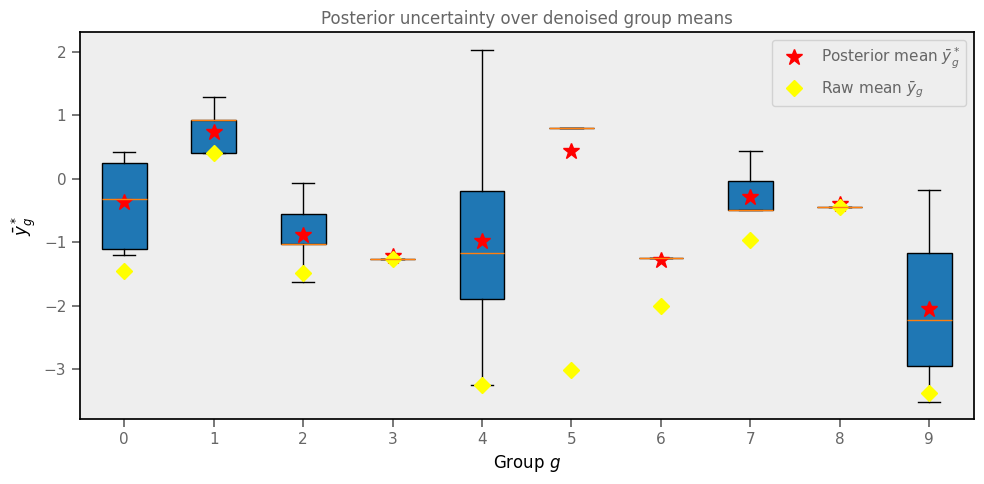

In [13]:

G, n = Y_train.shape

# Compute denoised mean for each posterior sample and each group
ystar = torch.zeros(len(samples), G)
for s_idx, state in enumerate(samples):
    Z = state["Z_GN"]                            # (G, n)
    ystar[s_idx] = (Y_train * Z).sum(dim=1) / Z.sum(dim=1)

# Raw (noisy) group means
y_bar = Y_train.mean(dim=1)                    # (G,)

# Posterior means of denoised means
ystar_mean = ystar.nanmean(dim=0)              # (G,)

# Box-plots
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(ystar.numpy(), positions=range(G),
                showfliers=False, patch_artist=True)

# Red star: posterior mean
ax.plot(range(G), ystar_mean, linestyle='none', color = "red", marker='*', markersize=12, label="Posterior mean $\\bar{y}^*_g$")

# Yellow diamond: raw mean
ax.plot(range(G), y_bar, linestyle='none', color='yellow', marker = 'D', markersize=8, label="Raw mean $\\bar{y}_g$")

ax.set_xlabel("Group $g$")
ax.set_ylabel("$\\bar{y}^*_g$")
ax.set_title("Posterior uncertainty over denoised group means")
ax.legend()
plt.tight_layout()
plt.show()


## YOUR CODE HERE (this should display the described plot when run)

## **Problem 6**: Posterior predictive of $z_{g,i}$ [Math, code]
In this problem you are going to derive and implement a Monte Carlo approximation for the posterior predictive probability that a new unseen data point in group $g$ is not anomalous---i.e.:
$$p(z^{\textrm{test}}_{g, i} = 1\mid \mathbf{x}^{\textrm{test}}_{g, i}, \mathbf{Y}, \mathbf{X})$$

**6a):** First, provide the mathematical form of your Monte Carlo approximation, which should involve posterior samples of latent variables (e.g., using $\rho^m_{g}$ to denote the $m^{\textrm{th}}$ posterior sample of variable $\rho_{g}$).


---

First, let $Z$ be all latent variables ($\rho_g, {\beta}_g, \sigma_g^2$, etc.):

$$
p(z^{\text{test}}_{g,i} = 1 \mid \mathbf{x}^{\text{test}}_{g,i}, \mathbf{Y}, \mathbf{X})
= \int p(z^{\text{test}}_{g,i} = 1 \mid {Z}, \mathbf{x}^{\text{test}}_{g,i}) \; p({Z} \mid \mathbf{Y}, \mathbf{X}) \; d{Z}
$$

where the first factor is the prior on $z$ from the model, $z_{g,i} \mid \rho_g \sim \text{Bernoulli}(\rho_g)$, so:

$$
p(z^{\text{test}}_{g,i} = 1 \mid {Z}, \mathbf{x}^{\text{test}}_{g,i}) = \rho_g
$$

Substituting:

$$
p(z^{\text{test}}_{g,i} = 1 \mid \mathbf{x}^{\text{test}}_{g,i}, \mathbf{Y}, \mathbf{X})
= \int \rho_g \; p({Z} \mid \mathbf{Y}, \mathbf{X}) \; d{Z}
= \mathbb{E}[\rho_g \mid \mathbf{Y}, \mathbf{X}]
$$

Since this is the posterior expectation of $\rho_g$ we approximate it with a MC average over our $M$ posteriors:

$$
p(z^{\textrm{test}}_{g, i} = 1\mid \mathbf{x}^{\textrm{test}}_{g, i}, \mathbf{Y}, \mathbf{X})
\approx \frac{1}{M} \sum_{m=1}^M \rho_g^{(m)}
$$


---

**6b):** Now implement your Monte Carlo estimator in the function `posterior_predictive_z`, and run the code so it prints out some test values.

In [14]:
Y_test, X_test = torch.load("data_test.pt")

def posterior_predictive_z_g(x, g, samples, hypers):
    """
    Compute the posterior predictive probability that a new unseen data point 
    in group g is not anomalous, i.e., p(z^{test}_{g, i} = 1 | x^{test}_{g, i}, Y, X).

    Args:
        x (torch.Tensor): Covariates for the new unseen data point.
        g (int): Group index for the new unseen data point.
        samples (list): List of posterior samples, where each sample is a state dictionary.
        hypers (dict): Dictionary of hyperparameters.

    NOTE: By default, we pass (x, g, samples, hypers), however this 
    may not require some of these inputs.

    Returns:
        torch.Tensor or float: Posterior predictive probability.
    """

    rho_samples = torch.tensor([s["rho_G"][g] for s in samples])
    
    return rho_samples.mean().item()


# Print the posterior predictive for the first test data point in each group.
print([posterior_predictive_z_g(X_test[g, 0], g, samples, hypers) for g in range(G)])


[0.8025489449501038, 0.898335337638855, 0.8285959959030151, 0.9271987080574036, 0.616038978099823, 0.5891146659851074, 0.814264178276062, 0.8437381386756897, 0.9289276003837585, 0.7239371538162231]


## **Problem 7**: Scaled pointwise predictive density [Math, code]
In this problem you are going to compute a Monte Carlo approximation to the **scaled pointwise predictive density (SPPD)** of the test data, defined as:

$$\textrm{SPPD} = \exp \left(\tfrac{1}{G \, n_{\textrm{test}}} \sum_{g=1}^G \sum_{i=1}^{n_{\textrm{test}}} \log p(y^{\textrm{test}}_{g,i} \mid \textbf{x}_{g,i}^{\textrm{test}}, \textbf{Y}^{\textrm{train}}, \textbf{X}^{\textrm{train}})\right)$$

where the term $\log p(y^{\textrm{test}}_{g,i} \mid \textbf{x}_{g,i}^{\textrm{test}}, \textbf{Y}^{\textrm{train}}, \textbf{X}^{\textrm{train}})$ is the (natural) log of the **posterior predictive density** of heldout test data point $(y^{\textrm{test}}_{g,i}, \textbf{x}_{g,i}^{\textrm{test}})$. 

SPPD is a measure of heldout predictive performance, which takes the geometric mean of the posterior predictive densities on the heldout test points. In this case, the same number of points $n_{\textrm{test}}$ have been heldout of each group $g$, making the total number of test points equal to $Gn_{\textrm{test}}$

In this problem, you will derive and implement a Monte Carlo approximation of SPPD which uses the posterior samples obtained during Gibbs sampling. 

**7a):** First, provide the mathematical form of your Monte Carlo approximation, which should involve posterior samples of latent variables (e.g., using $z^m_{g, i}$ to denote the $m^{\textrm{th}}$ posterior sample of variable $z_{g, i}$).


---

First step is to marginalize over the latent variables. As before $Z$ are the latent variables.

$$
p(y_{g,i}^{\text{test}} \mid \mathbf{x}_{g,i}^{\text{test}}, \mathbf{Y}, \mathbf{X}) = \int p(y_{g,i}^{\text{test}} \mid \mathbf{x}_{g,i}^{\text{test}}, {Z}) \; p({Z} \mid \mathbf{Y}, \mathbf{X}) \; d{Z}
$$

The posterior $p({Z} \mid \mathbf{Y}, \mathbf{X})$ is what the Gibbs sampler approximates with samples. So we replace the integral with a MC average:

$$
p(y_{g,i}^{\text{test}} \mid \mathbf{x}_{g,i}^{\text{test}}, \mathbf{Y}, \mathbf{X}) \approx \frac{1}{M} \sum_{m=1}^M p(y_{g,i}^{\text{test}} \mid \mathbf{x}_{g,i}^{\text{test}}, {Z}^{(m)})
$$

Given a posterior sample ${Z}^{(m)}$, the test point could be real or random. We marginalize over $z_{g,i}^{\text{test}}$:

$$
p(y_{g,i}^{\text{test}} \mid \mathbf{x}_{g,i}^{\text{test}}, {Z}^{(m)}) = \rho_g^{(m)} \cdot \mathcal{N}(y_{g,i}^{\text{test}} \mid {\mathbf{x}_{g,i}^{\text{test}}}^T \boldsymbol{\beta}_g^{(m)}, {\sigma_g^2}^{(m)}) +
$$
$$
+ (1 - \rho_g^{(m)}) \cdot \mathcal{N}(y_{g,i}^{\text{test}} \mid \mu_0, \sigma_0^2)
$$

Putting the probabities all together:

$$
\text{SPPD} \approx \exp (\frac{1}{G \cdot n_{\text{test}}} \sum_{g=1}^G \sum_{i=1}^{n_{\text{test}}} \log
$$
$$
\left[\frac{1}{M} \sum_{m=1}^M \left(\rho_g^{(m)} \cdot \mathcal{N}(y_{g,i}^{\text{test}} \mid {\mathbf{x}_{g,i}^{\text{test}}}^T \boldsymbol{\beta}_g^{(m)}, {\sigma_g^2}^{(m)}) + (1 - \rho_g^{(m)}) \cdot \mathcal{N}(y_{g,i}^{\text{test}} \mid \mu_0, \sigma_0^2)\right)\right] )
$$

---

**7b):** Now implement your Monte Carlo estimator. Your implementation should be numerically stable, and should compute everything in log-space, **using again the logsumexp trick**. You should **only** move out of log-space at the very end. After implementing `scaled_ppd`, run the code to print out the value of SPPD on the test data.

In [ ]:
def scaled_ppd(Y, X, samples, hypers):
    """Computes the scaled pointwise predictive density (PPD) for the test data.

    Args:
        Y (torch.Tensor): Observed responses for the test data.
        X (torch.Tensor): Covariates for the test data.
        samples (list): List of posterior samples, where each sample is a state dictionary.
        hypers (dict): Dictionary of hyperparameters.

    Returns:
        torch.Tensor or float: The scaled pointwise predictive density.
    """

    G, n_test, p = X.shape
    M = len(samples)
    mu_0 = hypers["mu_0"]
    sigmasq_0 = hypers["sigmasq_0"]

    log_mix = torch.zeros(M, G, n_test)

    for m, state in enumerate(samples):
        beta_GP = state["beta_GP"] # (G, p)
        sigmasq_G = state["sigmasq_G"] # (G,)
        rho_G = state["rho_G"] # (G,)

        # Log-likelihoods under each component
        mu_GN = torch.einsum("gnp,gp->gn", X, beta_GP)
        log_lik_real = Normal(mu_GN, torch.sqrt(sigmasq_G[:, None])).log_prob(Y) # (G, n_test)
        log_lik_junk = Normal(mu_0, sigmasq_0**0.5).log_prob(Y) # (G, n_test)

        log_score_real = torch.log(rho_G[:, None]) + log_lik_real
        log_score_junk = torch.log(1 - rho_G[:, None]) + log_lik_junk
        log_mix[m] = torch.logaddexp(log_score_real, log_score_junk)

    # = logsumexp over m - log(M)
    log_ppd = torch.logsumexp(log_mix, dim=0) - torch.log(torch.tensor(float(M)))  # (G, n_test)


    sppd = torch.exp(log_ppd.mean())

    return sppd


print(scaled_ppd(Y_test, X_test, samples, hypers))


tensor(0.2270)


## Submission Instructions


**Formatting:** check that your code does not exceed 80 characters in line width. You can set _Tools &rarr; Settings &rarr; Editor &rarr; Vertical ruler column_ to 80 to see when you've exceeded the limit. 

Download your notebook in .ipynb format and use the following commands to convert it to PDF. First, rename your file `<yourlastname>_hw2.ipynb`. Then run:
```
jupyter nbconvert --to webpdf <yourlastname>_hw2.ipynb
```

This uses a headless browser to render the notebook as a PDF (no LaTeX installation required). Math is rendered via MathJax, so it should look the same as in the notebook.

**Installing dependencies:**

```
pip install "nbconvert[webpdf]"
playwright install chromium
```

Getting this HW into PDF form isn't meant to be a burden. If the above doesn't work, one quick and easy approach is to open it as a Jupyter notebook, print, save to pdf. Just make sure your latex math answers aren't cut off so we can grade them.

Please post on Ed or come to OH if there are any other problems submitting the HW.

**Upload** your .pdf file to Gradescope. Please tag your questions!